In [49]:
import sys

import os
import glob

import h5py

import numpy as np

from astropy.io import fits

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from mrileyowens.stats import weighted_quantile

In [50]:
def compare():

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    catalog = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog)

    ids_endsley2024 = hdul_endsley2024[1].data['ID']

    m_uv_bins = ['bright', 'faint', 'vfaint']

    fig, ax = plt.subplots()

    for m_uv_bin in m_uv_bins:

        with h5py.File(f'{results}/ew/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits_ews_{m_uv_bin}.h5', 'r') as f:

            for i, id in enumerate(list(f.keys())):

                ew_posterior_me = f[id]['hb_ews'][:] + f[id]['oiii_ews'][:]
                probs = f[id]['probabilities'][:]

                ew_me, ew_lower, ew_upper = weighted_quantile(ew_posterior_me, probs, [0.5, 0.16, 0.84])

                ew_endsley2024, ew_endsley2024_lower, ew_endsley2024_upper = hdul_endsley2024[1].data['OIIIHbEw'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_l16'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_u84'][ids_endsley2024 == id][0]

                ax.errorbar(ew_me, ew_endsley2024, xerr=[[ew_me - ew_lower], [ew_upper - ew_me]], yerr=[[ew_endsley2024 - ew_endsley2024_lower], [ew_endsley2024_upper - ew_endsley2024]], color='black')

    ax.set_xlabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Me)')
    ax.set_ylabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Endsley et al. (2024))')

    # Create a one-to-one line on the figure
    ax.axline((1000,1000), slope=1, color='red', linestyle='dashed')

    ax.loglog()

    fig.savefig(f'{figs}/compare_ew.png', dpi=200, bbox_inches='tight')

<>:32: SyntaxWarning: invalid escape sequence '\A'
<>:33: SyntaxWarning: invalid escape sequence '\A'
<>:32: SyntaxWarning: invalid escape sequence '\A'
<>:33: SyntaxWarning: invalid escape sequence '\A'
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_80072/1063163492.py:32: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Me)')
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_80072/1063163492.py:33: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Endsley et al. (2024))')


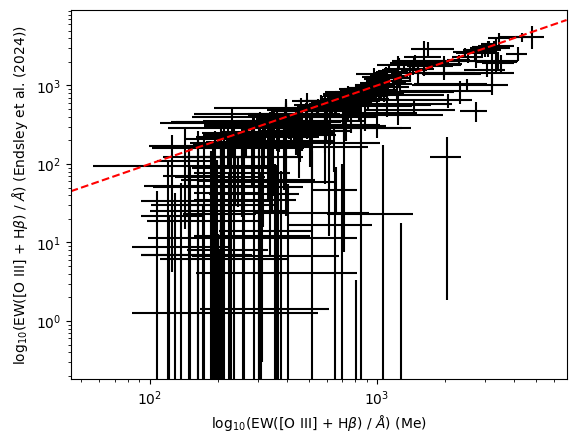

In [51]:
compare()